In [2]:
# Importing Libraries
import warnings
import os

# Hide all warnings (including TqdmWarning and Kagglehub)
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ariyoomotade/netflix-data-cleaning-analysis-and-visualization")

# Check the file names in the folder (usually it's netflix1.csv)
print("Files in the folder:", os.listdir(path))

# Form the full path to the file and read it
csv_path = os.path.join(path, "netflix1.csv")
df = pd.read_csv(csv_path)

# Check the result
print(f"Rows loaded: {len(df)}")

# Data Cleanup
# Convert 'date_added' to datetime without specifying the exact format
df['date_added'] = pd.to_datetime(df['date_added'])
#Add mew column "year_added"
df['year_added'] = pd.to_datetime(df['date_added']).dt.year

Files in the folder: ['netflix1.csv']
Rows loaded: 8790


### Inspection

#### View
 Notes
- View the first rows of data in the DataFrame using head().
- View the last few rows of the DataFrame using tail().

In [3]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021


In [4]:
df.tail()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas",2017
8786,s8798,TV Show,Zak Storm,Not Given,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,2018
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",2016
8788,s8784,TV Show,Yoko,Not Given,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV,2018
8789,s8786,TV Show,YOM,Not Given,Pakistan,2018-06-07,2016,TV-Y7,1 Season,Kids' TV,2018


### Get Info
Notes
To get a concise summary for the DataFrame we'll be using df.info.

This gives us:

- Total number of entries
- Number of columns
- Column name
- Count of non-null items in each column
- Data type of each column

Useful for exploring the data and getting a quick glance at the dataset.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   str           
 1   type          8790 non-null   str           
 2   title         8790 non-null   str           
 3   director      8790 non-null   str           
 4   country       8790 non-null   str           
 5   date_added    8790 non-null   datetime64[us]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   str           
 8   duration      8790 non-null   str           
 9   listed_in     8790 non-null   str           
 10  year_added    8790 non-null   int32         
dtypes: datetime64[us](1), int32(1), int64(1), str(8)
memory usage: 721.2 KB


##### Find Not NA Values
Good for data preprocessing to remove or fill missing values, or to make decisions based on the presence of data.

In [7]:
df.notna()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added
0,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
8785,True,True,True,True,True,True,True,True,True,True,True
8786,True,True,True,True,True,True,True,True,True,True,True
8787,True,True,True,True,True,True,True,True,True,True,True
8788,True,True,True,True,True,True,True,True,True,True,True


Which entries in a DataFrame are NA.

In [8]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
year_added      0
dtype: int64

### Data Cleaning

#### Date and Time

Let's sort our DataFrame by the release_date in descending order (from most recent date to least).

In [9]:
df.sort_values(by='release_year', ascending=False, inplace=True)
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added
6871,s1318,TV Show,Nadiya Bakes,Not Given,United Kingdom,2021-02-12,2021,TV-G,1 Season,"British TV Shows, International TV Shows, Real...",2021
541,s394,Movie,A Second Chance: Rivals!,Clay Glen,Australia,2021-07-23,2021,PG,91 min,"Children & Family Movies, Sports Movies",2021
531,s376,Movie,Resort to Love,Steven Tsuchida,Not Given,2021-07-29,2021,TV-14,102 min,"Comedies, Romantic Movies",2021
532,s373,Movie,Rurouni Kenshin: The Beginning,Keishi Otomo,Not Given,2021-07-30,2021,TV-MA,138 min,"Action & Adventure, International Movies",2021
533,s388,Movie,Mimi,Laxman Utekar,India,2021-07-27,2021,TV-14,132 min,"Comedies, Dramas, International Movies",2021
...,...,...,...,...,...,...,...,...,...,...,...
6491,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",United States,2017-03-31,1943,TV-PG,82 min,Documentaries,2017
6510,s8764,Movie,WWII: Report from the Aleutians,John Huston,United States,2017-03-31,1943,TV-PG,45 min,Documentaries,2017
6037,s8206,Movie,The Battle of Midway,John Ford,United States,2017-03-31,1942,TV-14,18 min,"Classic Movies, Documentaries",2017
5698,s7791,Movie,Prelude to War,Frank Capra,United States,2017-03-31,1942,TV-14,52 min,"Classic Movies, Documentaries",2017


#### Descriptive Statistics

For a basic overview we'll be using describe().

It gets the following (for columns with numeric data):
- count
- mean
- std
- min
 - max
 
Great for getting a quick overview of the basic stats for the table.
It automatically skips NaN values.

In [10]:
df.describe()

,date_added,release_year,year_added
count,8790,8790.000000,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163,2018.873606
min,2008-01-01 00:00:00,1925.000000,2008.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000
50%,2019-07-03 00:00:00,2017.000000,2019.000000
75%,2020-08-19 18:00:00,2019.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000
std,NaN,8.825466,1.573568


In [11]:
# Let's get the count of the values in each column within the entire DataFrame.
df.count()

show_id         8790
type            8790
title           8790
director        8790
country         8790
date_added      8790
release_year    8790
rating          8790
duration        8790
listed_in       8790
year_added      8790
dtype: int64

In [12]:
# Determine if there are duplicates
df.duplicated().sum()

np.int64(0)

#### Data Analysis

In [13]:
#Determining the number of titles for each type
table_general = df.groupby('type').size().reset_index(name='count')

table_general

,type,count
0,Movie,6126
1,TV Show,2664


In [14]:
# Distribution of Genres by Content Type
type_table = df.groupby('type')['listed_in'].value_counts().reset_index(name='total_count')

type_table

,type,listed_in,total_count
0,Movie,"Dramas, International Movies",362
1,Movie,Documentaries,359
2,Movie,Stand-Up Comedy,334
3,Movie,"Comedies, Dramas, International Movies",274
4,Movie,"Dramas, Independent Movies, International Movies",252
...,...,...,...
508,TV Show,"TV Comedies, TV Dramas, TV Horror",1
509,TV Show,"Crime TV Shows, TV Horror, TV Mysteries",1
510,TV Show,"TV Comedies, TV Horror, TV Thrillers",1
511,TV Show,"Kids' TV, Spanish-Language TV Shows, Teen TV S...",1


In [34]:
# Grouped Value Counts (Identical table to the previous one, but with a different layout)
type_table = df.groupby('type')['listed_in'].value_counts()

type_table

type     listed_in                                         
Movie    Dramas, International Movies                          362
         Documentaries                                         359
         Stand-Up Comedy                                       334
         Comedies, Dramas, International Movies                274
         Dramas, Independent Movies, International Movies      252
                                                              ... 
TV Show  TV Comedies, TV Dramas, TV Horror                       1
         Crime TV Shows, TV Horror, TV Mysteries                 1
         TV Comedies, TV Horror, TV Thrillers                    1
         Kids' TV, Spanish-Language TV Shows, Teen TV Shows      1
         Kids' TV, Reality TV, Science & Nature TV               1
Name: count, Length: 513, dtype: int64

#### Pivot Tables & Grouping

In [35]:

# Director Profiles by Region

# First, get rid of empty values ​​in key columns
df_clean = df.dropna(subset=['country', 'director'])

table = df_clean.groupby(['country', 'director'])['title'].agg([
      ('Count', 'count'),
      ('Titles', lambda x: ', '.join(x))
])

# Add the Total row manually to avoid index errors
total_count = table['Count'].sum()
table.loc[('Total', ''), :] = [total_count, 'All Movies & TV Shows']

table

Count  \
country      director                                        
Argentina    Alejandro De Grazia, Juan Stadler         1.0   
             Alejandro Doria                           2.0   
             Alejandro Hartmann                        1.0   
             Alejandro Montiel                         2.0   
             Ana Quiroga                               1.0   
...                                                    ...   
Vietnam      Van M. Pham                               1.0   
             Victor Vu                                 1.0   
West Germany Joachim Fest, Christian Herrendoerfer     1.0   
Zimbabwe     Tomas Brickhill                           1.0   
Total                                               8790.0   

                                                                                        Titles  
country      director                                                                           
Argentina    Alejandro De Grazia, Juan Stadler                        From Stress to Happiness  
             Alejandro Doria                        Esperando La Carroza, Esperando la carroza  
             Alejandro Hartmann                                Carmel: Who Killed Maria Marta?  
             Alejandro Montiel                                              Intuition, Perdida  
             Ana Quiroga                                         Lucha: Playing the Impossible  
...                                                                                        ...  
Vietnam      Van M. Pham                                                      Conjuring Spirit  
             Victor Vu                                                             Dreamy Eyes  
West Germany Joachim Fest, Christian Herrendoerfer                           Hitler - A Career  
Zimbabwe     Tomas Brickhill                                                          Cook Off  
Total                                                                    All Movies & TV Shows  

[4747 rows x 2 columns]

In [36]:
# Top 10 Countries by Content Volume with Titles List

# First, get rid of empty values ​​in key columns
df_clean_data = df.dropna(subset=['country', 'director'])

# 2. Create Pivot Table
pivot_table = pd.pivot_table(
    df_clean_data, 
    index=['country'], 
    values='title', 
    aggfunc={'title': [len, lambda x: ', '.join(x)]}
)

# 3. Rename columns
pivot_table.columns = ['All Titles', 'Count']

# 4. Sotr the values
pivot_table = pivot_table.sort_values(by='Count', ascending=False)

pivot_table.head(10)

,All Titles,Count
country,,
United States,"Firefly Lane, Tiffany Haddish Presents: They R...",3240
India,"Mimi, Bombay Begums, Mighty Little Bheem: Kite...",1057
United Kingdom,"Nadiya Bakes, Fate: The Winx Saga - The Afterp...",638
Pakistan,"Heist, So Not Worth It, Eden, You Are My Sprin...",421
Not Given,"Resort to Love, Rurouni Kenshin: The Beginning...",287
Canada,"Blown Away, Polly Pocket, Vivo, Black Summer, ...",271
Japan,"Creator's File: GOLD, The Seven Deadly Sins, T...",259
South Korea,"Kingdom: Ashin of the North, Busted!, Vincenzo...",214
France,"Lupin, The Swarm, Oxygen, Sentinelle, Dealer, ...",213


#### Visualization

#### Content Type Distribution (Movies vs. TV Shows)

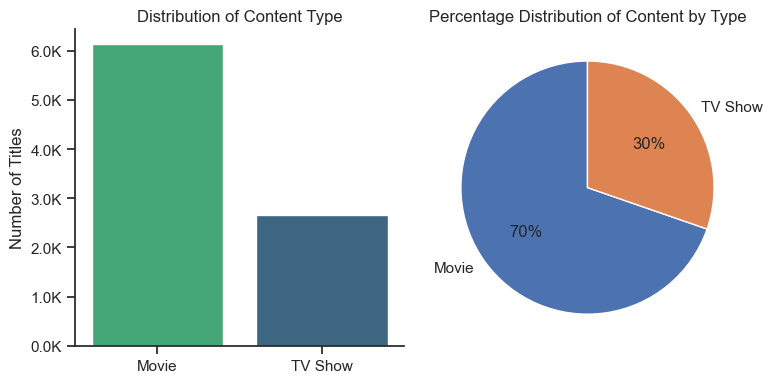

In [18]:
# Style settings
sns.set_theme(style='ticks')

#Create a grid of 1 row by 2 columns
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# 2. Countplot 
sns.countplot(data=df, x='type', palette='viridis', ax=ax[0])
ax[0].set_title('Distribution of Content Type')
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Titles')
ax[0].invert_xaxis()
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{y/1000:.1f}K'))

# 3. Pie Chart
type_counts = df['type'].value_counts()
ax[1].pie(type_counts, labels=type_counts.index, autopct='%.0f%%', startangle=90)
ax[1].set_title('Percentage Distribution of Content by Type')

# Remove extra lines (despine) and align
sns.despine()
fig.tight_layout()

plt.show()

Movies vs TV Shows Over Time

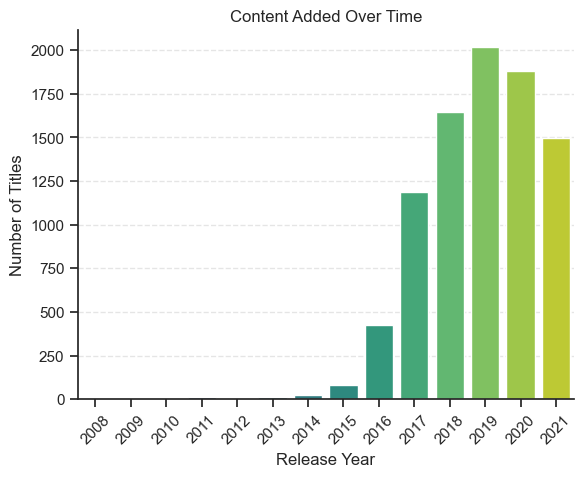

In [19]:
# Style settings
sns.set_theme(style='ticks')

sns.countplot(df, x='year_added', stat='count', palette='viridis')

plt.title('Content Added Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

# Remove extra lines (despine) and align
sns.despine()
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()


Type Of Content Added Over Time

In [37]:
#Content Addition Dynamics by Year and Type

df_plot = df.groupby(['year_added', 'type']).size().reset_index(name='count')

df_plot

,year_added,type,count
0,2008,Movie,1
1,2008,TV Show,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,13
5,2012,Movie,3
6,2013,Movie,6
7,2013,TV Show,5
8,2014,Movie,19
9,2014,TV Show,5


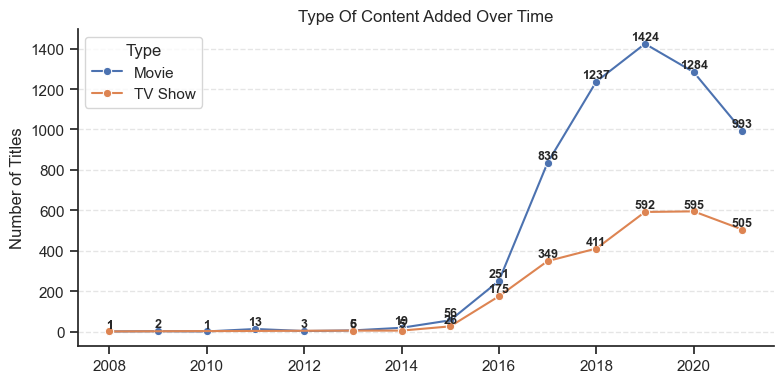

In [21]:
# Style settings
sns.set_theme(style='ticks')

fig, ax = plt.subplots(figsize=(8, 4))


sns.lineplot(data=df_plot, x='year_added', y='count', hue='type', marker='o', ax=ax)

# Adding values ​​above points
for t in df_plot['type'].unique():
    subset = df_plot[df_plot['type'] == t]
    for x, y in zip(subset['year_added'], subset['count']):
        ax.text(x, y + 4, f'{int(y)}', 
                ha='center', va='bottom', 
                fontsize=9, fontweight='semibold')


ax.legend(title='Type', loc='upper left')
ax.set_title('Type Of Content Added Over Time')
ax.set_xlabel('')
ax.set_ylabel('Number of Titles')

# Grid and layout
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
sns.despine()
fig.tight_layout()

plt.show()

Release Year Distribution

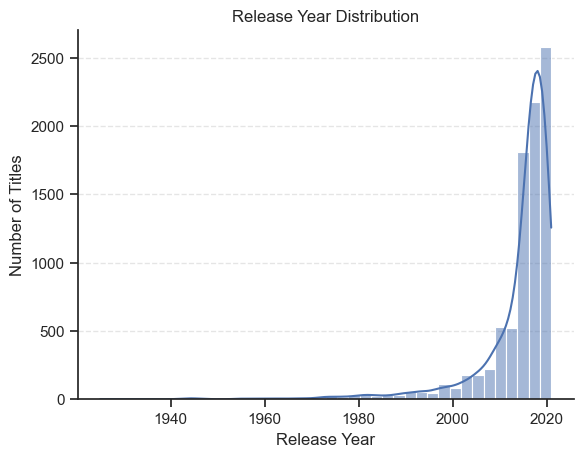

In [22]:
# Style settings
sns.set_theme(style='ticks')

sns.histplot(df['release_year'],bins=40, kde=True)

plt.title('Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
# Remove extra lines (despine) and align
sns.despine()
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()


Top 10 Countries with Most Content

In [23]:
top_10_countries = df['country'].value_counts().reset_index().head(10)
top_10_countries

,country,count
0,United States,3240
1,India,1057
2,United Kingdom,638
3,Pakistan,421
4,Not Given,287
5,Canada,271
6,Japan,259
7,South Korea,214
8,France,213
9,Spain,182


Top 10 Countries by Content

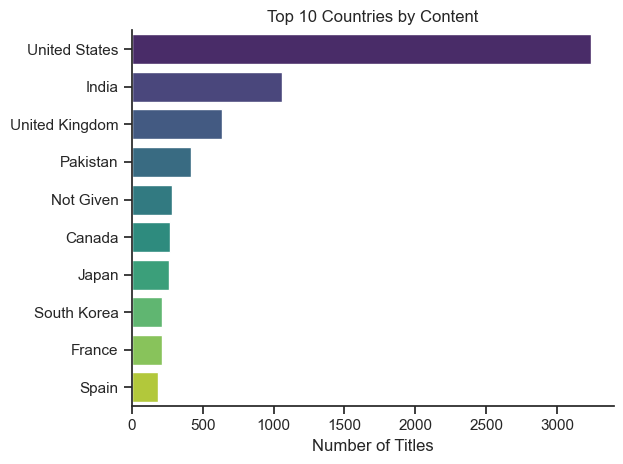

In [24]:
top_10_countries = df['country'].value_counts().reset_index().head(10)
sns.set_theme(style='ticks')

# Top 10 Countries by Content

sns.barplot(data=top_10_countries, x='count', y='country', palette='viridis')

plt.title('Top 10 Countries by Content')
plt.xlabel('Number of Titles')
plt.ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

Content Rating Distribution

In [25]:
top_rating = df['rating'].value_counts().reset_index().head(10)

top_rating

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


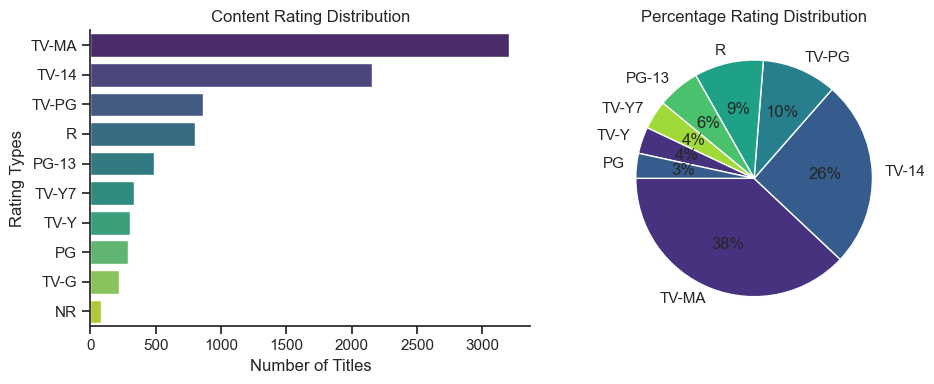

In [26]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches((10, 4)) 

sns.set_theme(style='ticks')

# Distribution of Rating
plt.subplot(1, 2, 1)
sns.barplot(data=top_rating, x='count', y='rating', palette='viridis')

plt.title('Content Rating Distribution')
plt.xlabel('Number of Titles')
plt.ylabel('Rating Types')


plt.subplot(1, 2, 2)
plt.pie(top_rating['count'][:8], labels=top_rating['rating'][:8], autopct='%.0f%%', colors=sns.color_palette('viridis'), startangle=180)
plt.title('Percentage Rating Distribution')
plt.xlabel('')
plt.ylabel('')


sns.despine()
plt.tight_layout()
plt.show()

Rating vs Content Type

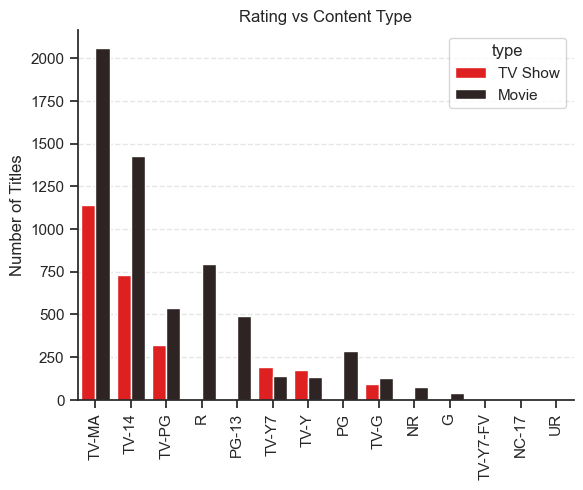

In [27]:
# Style settings
sns.set_theme(style='ticks')

sns.countplot(df, x='rating', stat='count', palette='dark:red_r', hue='type', order=df['rating'].value_counts().index)

plt.title('Rating vs Content Type')
plt.xlabel('')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90)

# Remove extra lines (despine) and align
sns.despine()
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

Top 10 Directors with the Most Titles

In [28]:
top_10_directors = df['director'].value_counts().reset_index()[1:10]

top_10_directors

,director,count
1,Rajiv Chilaka,20
2,Alastair Fothergill,18
3,"Raúl Campos, Jan Suter",18
4,Marcus Raboy,16
5,Suhas Kadav,16
6,Jay Karas,14
7,Cathy Garcia-Molina,13
8,Martin Scorsese,12
9,Jay Chapman,12


Top 10 Directors 

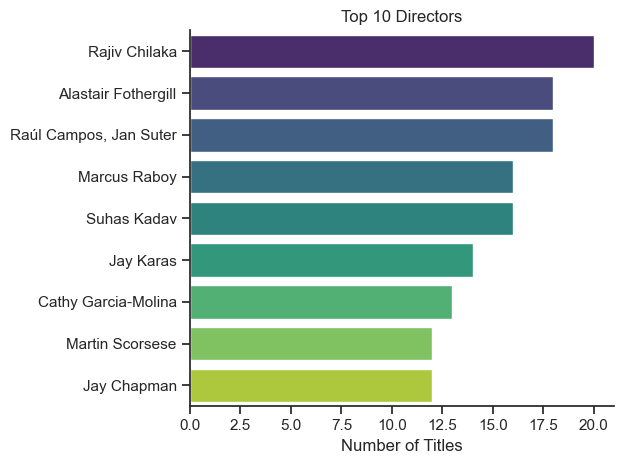

In [29]:
top_10_directors = df['director'].value_counts().reset_index()[1:10]
sns.set_theme(style='ticks')

# Top 10 Directors 

sns.barplot(data=top_10_directors, x='count', y='director', palette='viridis')

plt.title('Top 10 Directors')
plt.xlabel('Number of Titles')
plt.ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

Top 10 genres in descending order

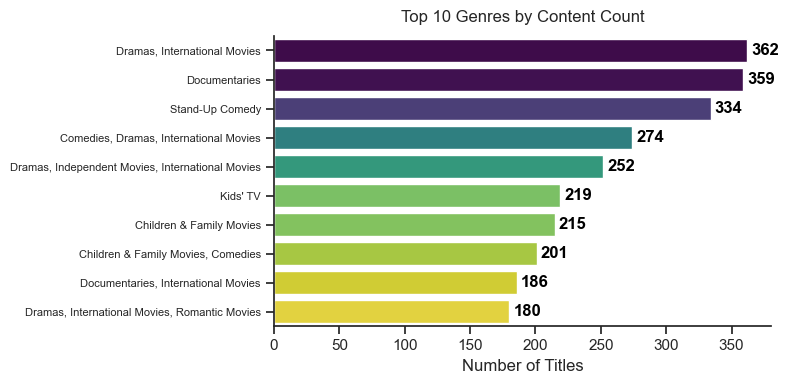

In [30]:
# Top 10 genres in descending order
top_10_genres = df['listed_in'].value_counts().head(10).reset_index()
top_10_genres.columns = ['genre', 'count']

# Style settings
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))

# Graph construction
ax = sns.barplot(
    data=top_10_genres, 
    x='count', 
    y='genre', 
    hue='count', 
    palette='viridis_r', 
    legend=False
)

# Adding numerical values ​​to the extremities
for i, v in enumerate(top_10_genres['count']):
    ax.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.title('Top 10 Genres by Content Count', fontsize=12, pad=10)
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.yticks(fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

In [38]:
#Top 10 Genres Market Share Analysis

# 1. Count the total number of original movies/series
total_titles = len(df)

#2. Count the number for each genre
genre_counts = df['listed_in'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

# 3. Add a column with a percentage of the TOTAL number of titles
genre_counts['percentage'] = (genre_counts['count'] / total_titles) * 100

# TOP Genres
top_10_genres = genre_counts.head(10)
print(top_10_genres)

                                              genre  count  percentage
0                      Dramas, International Movies    362    4.118316
1                                     Documentaries    359    4.084187
2                                   Stand-Up Comedy    334    3.799772
3            Comedies, Dramas, International Movies    274    3.117179
4  Dramas, Independent Movies, International Movies    252    2.866894
5                                          Kids' TV    219    2.491468
6                          Children & Family Movies    215    2.445961
7                Children & Family Movies, Comedies    201    2.286689
8               Documentaries, International Movies    186    2.116041
9     Dramas, International Movies, Romantic Movies    180    2.047782


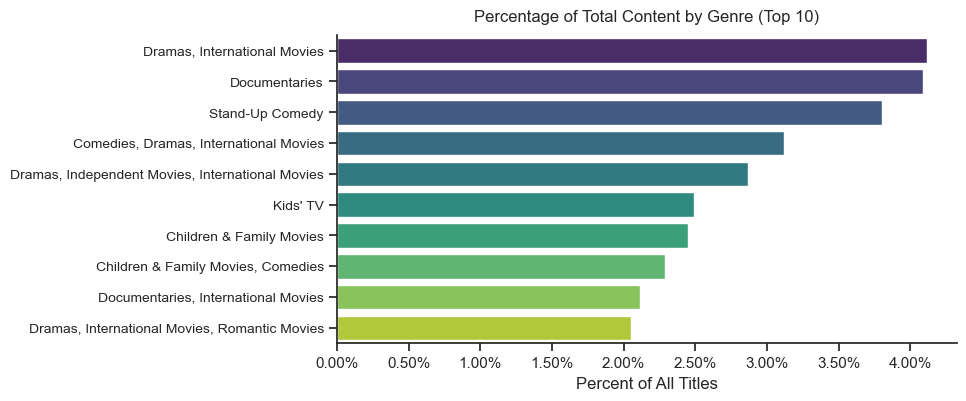

In [32]:
import matplotlib.ticker as mtick

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=top_10_genres, x='percentage', y='genre', palette='viridis')


ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.title('Percentage of Total Content by Genre (Top 10)', fontsize=12, pad=10)
plt.xlabel('Percent of All Titles')
plt.ylabel('')
plt.yticks(fontsize=10)
sns.despine()
plt.show()